# Regression Coefficient Instability

Regression analysis allows us to estimate coefficients in a function which approximately relates multiple data sets. We hypothesize a specific form for this function and then find coefficients which fit the data well, working under the assumption that deviations from the model can be considered noise.

When building such a model, we accept that it cannot perfectly predict the dependent variable. Here we would like to evaluate the accuracy of the model not by how well it explains the dependent variable, but by how *stable* it is (that is, how stable the regression coefficients are) with respect to new data. If, after all, a model is a good fit, but only for the particular data we happened to choose, then we cannot assume that the model will generalize — i.e., that similar (but not identical) datasets would produce truly comparable regression coefficients if we modeled them individually. Otherwise, we cannot assume that the model isn't simply an artifact of the particular sample of data we happened to choose, and that it will also be predictive of new data points.

For this illustration, we will be using linear regressions, but the same considerations apply for all regression models. Below we define a wrapper function for the linear regression from `statsmodels` so we can use it later.

In [19]:
import seaborn as sns
import numpy as np
import statsmodels.api as sm
import scipy as sp
import yfinance as yf
from statsmodels import regression, stats
from matplotlib import pyplot as plt

We will define a function for our linear regression

In [2]:
def linear_regression(X, Y):
  X = sm.add_constant(X)
  model = regression.linear_model.OLS(Y, X).fit()
  return model.params[0], model.params[1] # Return the intercept and slope

#### Biased noise

The noise we choose for the data affects the model generated, and unevenly distributed noise can lead to an inaccurate model.

Below, the particular sample we are drawing from a normal distribution, but because we do not have very many data points, the distributed noise can lead to an inaccurate model. If we took more measurements, both of the regression coefficients would move toward zero; with this small sample size, we get a significant downward bias.

Regression Coefficients: Intercept (a) = 0.2003, Slope (b) = -0.0086


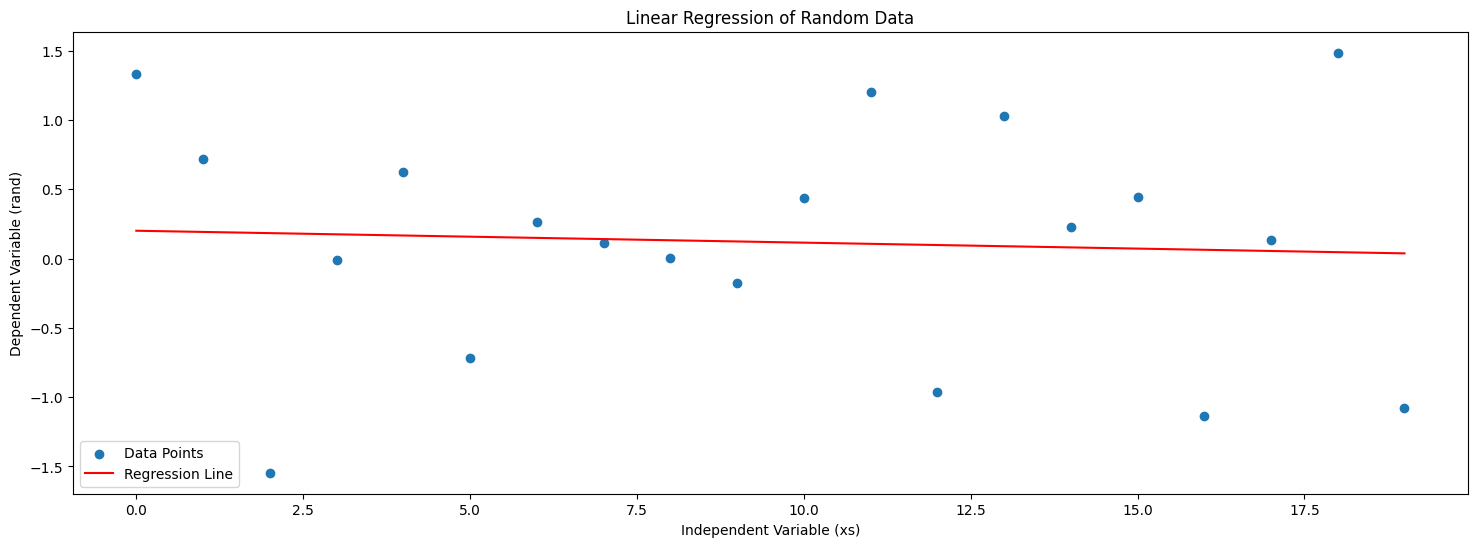

In [5]:
np.random.seed(10)

rand = np.random.randn(20) # we will draw observations from a normal distribution with mean 0 and standard deviation 1
xs = np.arange(20) # we will use the numbers 0 to 19 as our independent variable, which will be the same for all our regressions.
a, b = linear_regression(xs, rand) 

# Plot the raw data and the regression line
print(f"Regression Coefficients: Intercept (a) = {a:.4f}, Slope (b) = {b:.4f}")

plt.figure(figsize=(18, 6))
plt.scatter(xs, rand, label='Data Points')
regression_line = a + b * xs
plt.plot(xs, regression_line, color='red', label='Regression Line')
plt.title('Linear Regression of Random Data')
plt.xlabel('Independent Variable (xs)')
plt.ylabel('Dependent Variable (rand)')
plt.legend()
plt.show()

We can also use ```seaborn``` regression plot to visualise

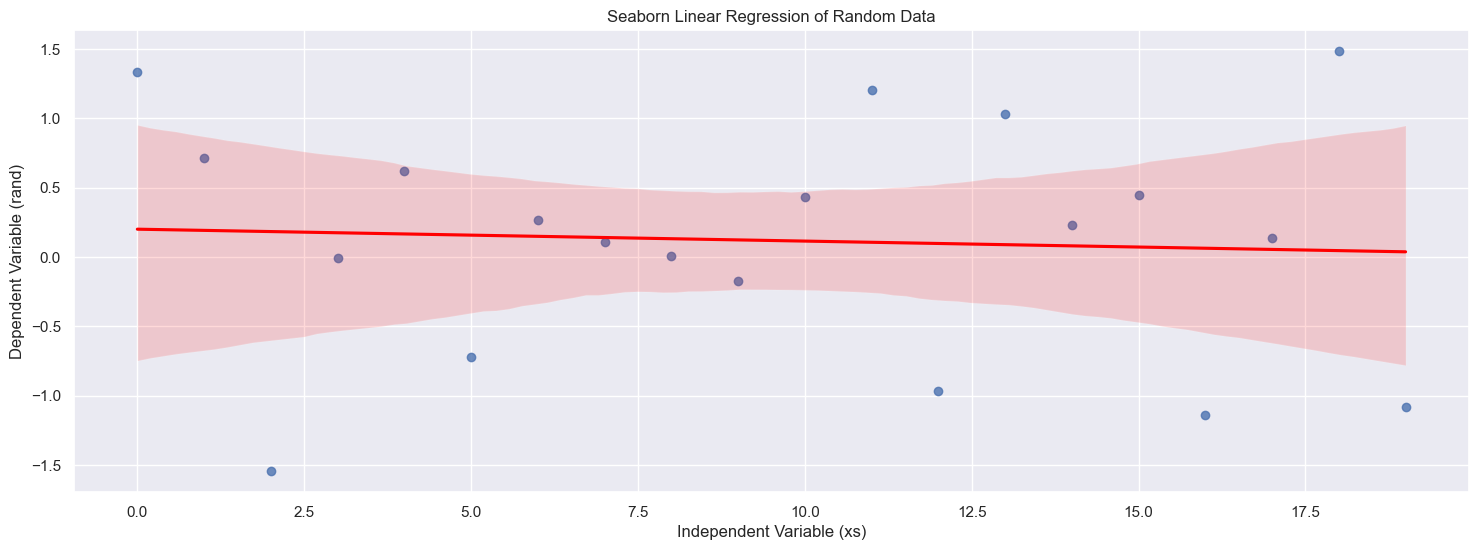

In [18]:
sns.regplot(x=xs, y=rand, line_kws={'color': 'red'})
sns.set_theme(rc={'figure.figsize':(16,6)})
plt.title('Seaborn Linear Regression of Random Data')
plt.xlabel('Independent Variable (xs)')
plt.ylabel('Dependent Variable (rand)')
plt.show()

Remarks:

---

Do note that regression analysis is very sensitive to outliers. Sometimes these outliers contain information, in which case we want to take them into account; however, in cases like the one above, they simply represent random noise. 

Although we often have many more data points than in the example above, we could still have (for example) fluctuations on the order of weeks or months, which then significantly change the regression coefficients.

#### Regime Changes

A **regime change** (or **structural break**) is when something changes in the process generating the data, causing future samples to follow a different distribution.

Below, we can see that there is a regime change at the end of 2007 (in red) on the whole data set (yellow). In this case our regression model will not be predictive of future data points since the underlying system is no longer the same as in the sample.

In fact, regression analysis assumes that the errors are uncorrelated and have constant variance, which is often not the case if there is a regime change.

/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_3099/3212156785.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_data = yf.download('SPY', start=start, end=end)['Close']
[*********************100%***********************]  1 of 1 completed
/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_3099/390491165.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return model.params[0], model.params[1] # Return the intercept and slope


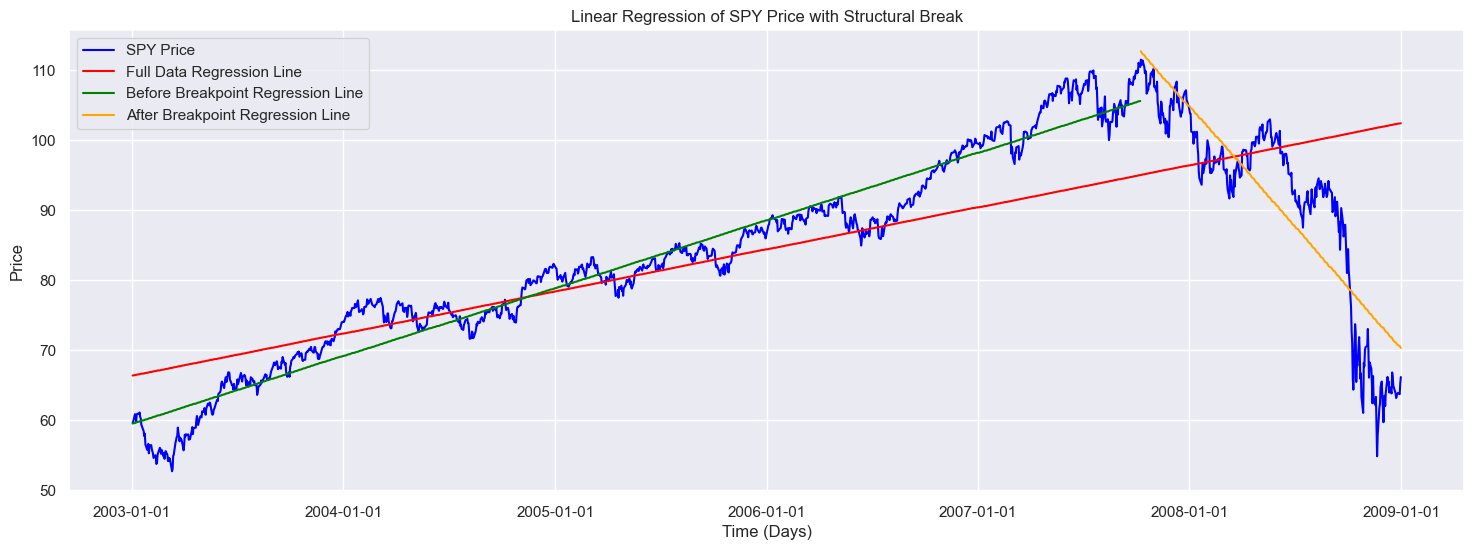

In [33]:
start = '2003-01-01'
end = '2009-01-01'

price_data = yf.download('SPY', start=start, end=end)['Close']

# Manuall set a breakpoint where we think the structural break occurs
breakpoint = 1200
xs = np.arange(len(price_data))
xs2 = np.arange(breakpoint)
xs3 = np.arange(len(price_data) - breakpoint)

# Perform linear regression on the entire dataset, the data up to the breakpoint, and the data after the breakpoint
a_full, b_full = linear_regression(xs, price_data)
a_before, b_before = linear_regression(xs2, price_data[:breakpoint])
a_after, b_after = linear_regression(xs3, price_data[breakpoint:])

y_hat_1 = a_full + b_full * xs
y_hat_2 = a_before + b_before * xs2
y_hat_3 = a_after + b_after * xs3

# Plot the raw data and the regression lines
_, ax = plt.subplots(figsize=(18, 6))
ax.plot(price_data.index, price_data.values, label='SPY Price', color='blue')
ticks = ax.get_xticks()
ax.set_xticks(ticks)

ax.plot(price_data.index, y_hat_1, color='red', label='Full Data Regression Line')
ax.plot(price_data.index[:breakpoint], y_hat_2, color='green', label='Before Breakpoint Regression Line')
ax.plot(price_data.index[breakpoint:], y_hat_3, color='orange', label='After Breakpoint Regression Line')
plt.title('Linear Regression of SPY Price with Structural Break')
plt.xlabel('Time (Days)')
plt.ylabel('Price')
plt.legend()
plt.show()

As expected, the more pieces we break our data set into, the more precisely we can fit it. It is important to avoid fitting noise, which will always fluctuate and is not predictive. We can test for the existence of a structural break, either at a particular point we have identified or in general. Below we use a test from `statsmodels` which computes the probability of observing the data if there were no breakpoint.

In [35]:
stats.diagnostic.breaks_cusumolsresid(regression.linear_model.OLS(price_data.values, sm.add_constant(xs)).fit().resid)[1]

2.104346973528527e-52

#### Multicollinearity

As for the above examples, we were only considering regressions of one dependent variable against one independent one. However, we can also have multiple independent variables. This leads to instability when the independent variables are highly correlated.

Imagine we are using two independent variables, $X_1$ and $X_2$, which are very highly correlated. Then the coefficients may shift drastically if we add a new observation that is slightly better explained by one than the other. In that case, the choice of coefficients will depend on the particular linear regression algorithm used.

In the extreme case where $X_1 = X_2$, then the coefficients become completely indeterminate.

Below, we run a multiple linear regression in which the independent variables are highly correlated. If we take our sample period to be 2013-01-01 to 2015-01-01, then the coefficients are approximately 0.25 and 1. But if we extend the period to 2015-06-01, the coefficients become approximately 0.18 and 2.0, respectively.

/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_3099/162273146.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  b1 = yf.download('SPY', start=start, end=end)['Close']
[*********************100%***********************]  1 of 1 completed
/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_3099/162273146.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  b2 = yf.download('MDY', start=start, end=end)['Close']
[*********************100%***********************]  1 of 1 completed
/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_3099/162273146.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  asset = yf.download('V', start=start, end=end)['Close']
[*********************100%***********************]  1 of 1 completed


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.853
Model:                            OLS   Adj. R-squared:                  0.853
Method:                 Least Squares   F-statistic:                     1459.
Date:                Thu, 26 Feb 2026   Prob (F-statistic):          1.19e-209
Time:                        23:51:22   Log-Likelihood:                -1159.3
No. Observations:                 504   AIC:                             2325.
Df Residuals:                     501   BIC:                             2337.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -11.7276      1.366     -8.588      0.0

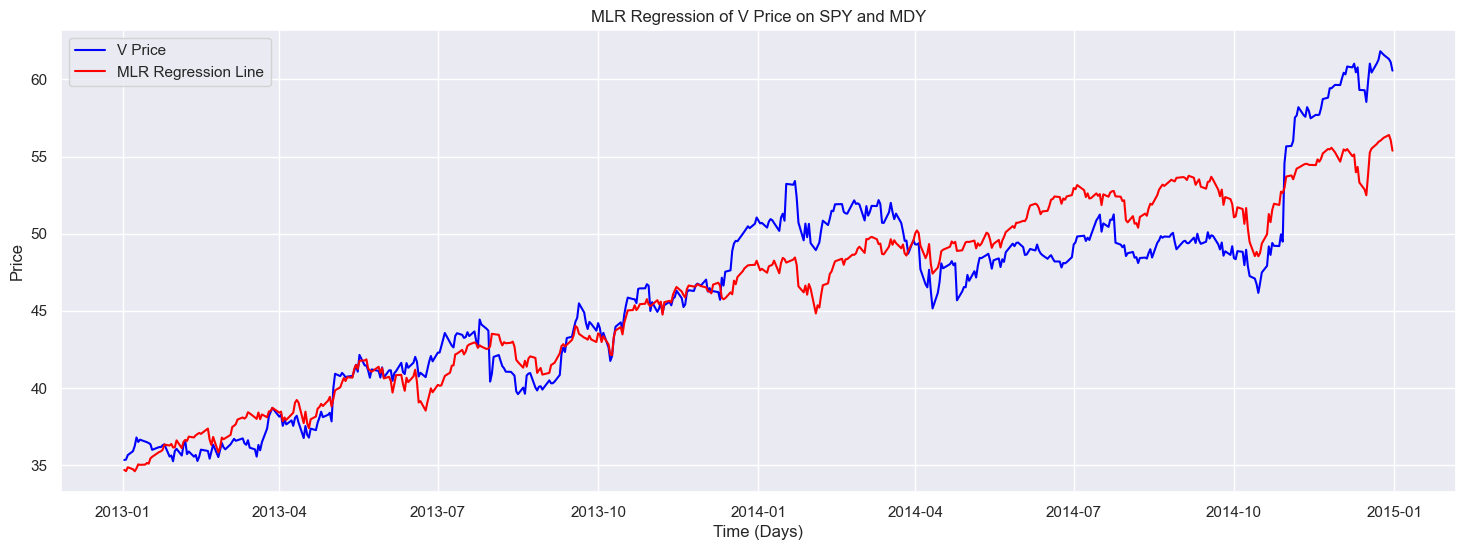

In [39]:
start = '2013-01-01'
end = '2015-01-01'

b1 = yf.download('SPY', start=start, end=end)['Close']
b2 = yf.download('MDY', start=start, end=end)['Close']
asset = yf.download('V', start=start, end=end)['Close']

mlr = regression.linear_model.OLS(asset.values, sm.add_constant(np.column_stack((b1.values, b2.values)))).fit()
print(mlr.summary())

prediction = mlr.params[0] + mlr.params[1] * b1.values + mlr.params[2] * b2.values
print("Constant: ", mlr.params[0], "MLR Beta for SPY: ", mlr.params[1], "MLR Beta for MDY: ", mlr.params[2])

# Plot the asset pricing data and the MLR regression line
plt.figure(figsize=(18, 6))
plt.plot(asset.index, asset.values, label='V Price', color='blue')
plt.plot(asset.index, prediction, color='red', label='MLR Regression Line')
plt.title('MLR Regression of V Price on SPY and MDY')
plt.xlabel('Time (Days)')
plt.ylabel('Price')
plt.legend()
plt.show()

/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_3099/3745827925.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  b1 = yf.download('SPY', start=start, end=end)['Close']
[*********************100%***********************]  1 of 1 completed
/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_3099/3745827925.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  b2 = yf.download('MDY', start=start, end=end)['Close']
[*********************100%***********************]  1 of 1 completed
/var/folders/5v/9xrz7nmd29s2z029pvbqs8r00000gn/T/ipykernel_3099/3745827925.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  asset = yf.download('V', start=start, end=end)['Close']
[*********************100%***********************]  1 of 1 completed


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.894
Method:                 Least Squares   F-statistic:                     2557.
Date:                Thu, 26 Feb 2026   Prob (F-statistic):          2.87e-295
Time:                        23:54:06   Log-Likelihood:                -1452.8
No. Observations:                 606   AIC:                             2912.
Df Residuals:                     603   BIC:                             2925.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -21.7292      1.187    -18.302      0.0

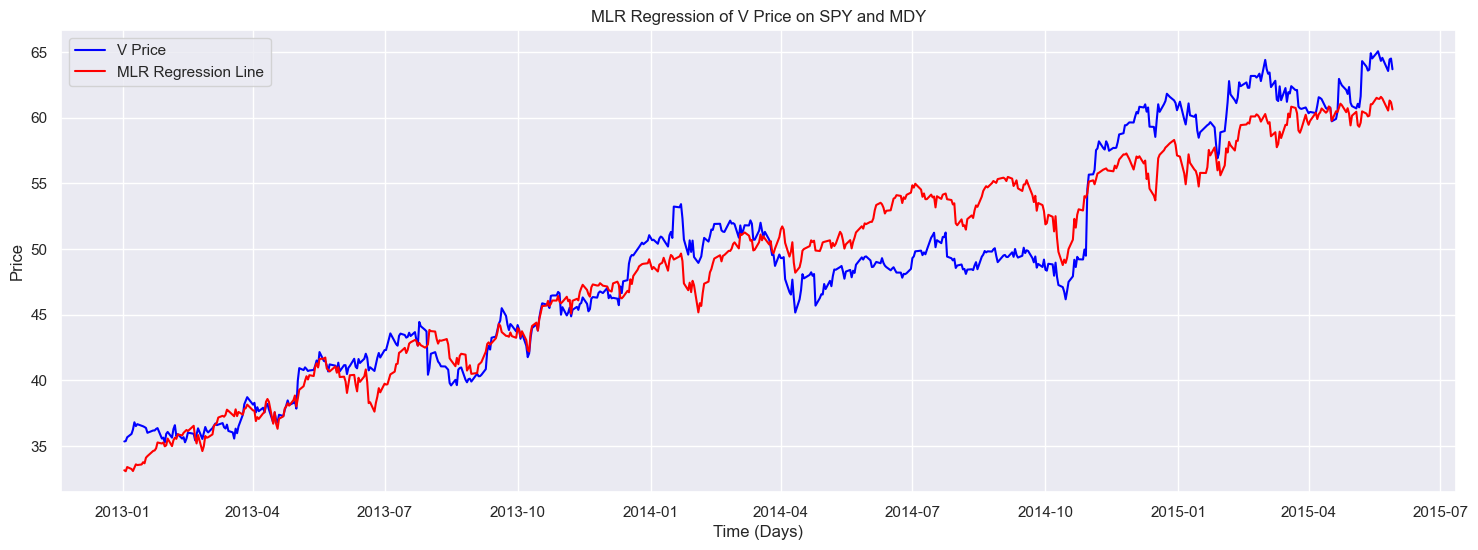

In [40]:
start = '2013-01-01'
end = '2015-06-01'

b1 = yf.download('SPY', start=start, end=end)['Close']
b2 = yf.download('MDY', start=start, end=end)['Close']
asset = yf.download('V', start=start, end=end)['Close']

mlr = regression.linear_model.OLS(asset.values, sm.add_constant(np.column_stack((b1.values, b2.values)))).fit()
print(mlr.summary())

prediction = mlr.params[0] + mlr.params[1] * b1.values + mlr.params[2] * b2.values
print("Constant: ", mlr.params[0], "MLR Beta for SPY: ", mlr.params[1], "MLR Beta for MDY: ", mlr.params[2])

# Plot the asset pricing data and the MLR regression line
plt.figure(figsize=(18, 6))
plt.plot(asset.index, asset.values, label='V Price', color='blue')
plt.plot(asset.index, prediction, color='red', label='MLR Regression Line')
plt.title('MLR Regression of V Price on SPY and MDY')
plt.xlabel('Time (Days)')
plt.ylabel('Price')
plt.legend()
plt.show()